# Recalculate Reasoning Tokens Using Model Tokenizer

This notebook recalculates the `reasoning_tokens` field in JSONL files using the actual model tokenizer instead of the approximation (chars/4).

In [2]:
import json
import re
from pathlib import Path
from tqdm.auto import tqdm
from transformers import AutoTokenizer

# Configuration
MODEL_PATH = "/mnt/dataset1/pretrained_fm/gpt-oss-20b"  # Change this to your model path
INPUT_FILE = "/home/vlai-gpt-oss/LLaMA-OSS/LLaMA-Factory/data/0_raw/compmath/compmath_train_low.jsonl"  # Your input file
OUTPUT_FILE = "/home/vlai-gpt-oss/LLaMA-OSS/LLaMA-Factory/data/0_raw/compmath/compmath_train_low1.jsonl"  # Output file with recalculated tokens

## 1. Load Tokenizer

In [3]:
print(f"Loading tokenizer from: {MODEL_PATH}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, trust_remote_code=True)
print(f"Tokenizer loaded: {tokenizer.__class__.__name__}")
print(f"Vocab size: {len(tokenizer)}")

Loading tokenizer from: /mnt/dataset1/pretrained_fm/gpt-oss-20b
Tokenizer loaded: PreTrainedTokenizerFast
Vocab size: 200019


## 2. Define Functions

In [4]:
def extract_thinking(response: str) -> str:
    """
    Extract content inside <think> tags.
    
    Args:
        response: Full response with <think> tags
        
    Returns:
        Thinking content (empty string if no tags found)
    """
    think_pattern = r'<think>(.*?)</think>'
    matches = re.findall(think_pattern, response, re.DOTALL)
    
    if matches:
        return matches[0].strip()
    
    return ""


def count_tokens(text: str, tokenizer) -> int:
    """
    Count tokens in text using the model tokenizer.
    
    Args:
        text: Text to tokenize
        tokenizer: Model tokenizer
        
    Returns:
        Number of tokens
    """
    if not text:
        return 0
    
    tokens = tokenizer.encode(text, add_special_tokens=False)
    return len(tokens)


def recalculate_reasoning_tokens(record: dict, tokenizer) -> dict:
    """
    Recalculate reasoning_tokens field using model tokenizer.
    
    Args:
        record: JSON record
        tokenizer: Model tokenizer
        
    Returns:
        Updated record
    """
    response = record.get('response', '')
    
    if response:
        # Extract thinking content
        thinking = extract_thinking(response)
        
        # Count tokens using model tokenizer
        token_count = count_tokens(thinking, tokenizer)
        
        # Update record
        record['reasoning_tokens'] = float(token_count)
        
        # Store old value for comparison (optional)
        if 'reasoning_tokens_old' not in record:
            old_value = record.get('reasoning_tokens', 0.0)
            if old_value != token_count:
                record['reasoning_tokens_old'] = old_value
    
    return record

## 3. Test on Single Example

In [5]:
# Test example
test_response = "<think>Solve congruence 3x ≡ 4y-1 mod35. Find x intercept: y=0 => 3x ≡ -1 mod35.</think> \\boxed{32}"

thinking = extract_thinking(test_response)
print("Thinking text:")
print(thinking)
print()

# Count tokens
token_count = count_tokens(thinking, tokenizer)
print(f"Token count: {token_count}")

# Compare with char/4 approximation
char_approx = len(thinking) / 4.0
print(f"Char/4 approximation: {char_approx:.1f}")
print(f"Difference: {abs(token_count - char_approx):.1f} tokens")

Thinking text:
Solve congruence 3x ≡ 4y-1 mod35. Find x intercept: y=0 => 3x ≡ -1 mod35.

Token count: 35
Char/4 approximation: 18.2
Difference: 16.8 tokens


## 4. Process File

In [6]:
input_path = Path(INPUT_FILE)
output_path = Path(OUTPUT_FILE)

if not input_path.exists():
    print(f"Error: Input file not found: {input_path}")
else:
    print(f"Processing: {input_path}")
    print(f"Output:     {output_path}")
    print()
    
    # Count total lines
    total_lines = sum(1 for line in open(input_path) if line.strip())
    print(f"Total records: {total_lines}")
    print()
    
    # Process file
    processed = 0
    differences = []
    
    with open(input_path, 'r', encoding='utf-8') as fin, \
         open(output_path, 'w', encoding='utf-8') as fout:
        
        for line in tqdm(fin, total=total_lines, desc="Processing"):
            line = line.strip()
            if not line:
                continue
            
            try:
                record = json.loads(line)
                
                # Store old value for comparison
                old_tokens = record.get('reasoning_tokens', 0.0)
                
                # Recalculate
                updated_record = recalculate_reasoning_tokens(record, tokenizer)
                
                # Track difference
                new_tokens = updated_record.get('reasoning_tokens', 0.0)
                diff = abs(new_tokens - old_tokens)
                differences.append(diff)
                
                # Write output
                fout.write(json.dumps(updated_record, ensure_ascii=False) + '\n')
                processed += 1
                
            except json.JSONDecodeError:
                continue
            except Exception as e:
                print(f"Error processing line: {e}")
                continue
    
    print(f"\nProcessed: {processed} records")
    print(f"Output saved to: {output_path}")

Processing: /home/vlai-gpt-oss/LLaMA-OSS/LLaMA-Factory/data/0_raw/compmath/compmath_train_low.jsonl
Output:     /home/vlai-gpt-oss/LLaMA-OSS/LLaMA-Factory/data/0_raw/compmath/compmath_train_low1.jsonl

Total records: 16524



Processing: 100%|██████████| 16524/16524 [00:04<00:00, 4049.76it/s]


Processed: 16524 records
Output saved to: /home/vlai-gpt-oss/LLaMA-OSS/LLaMA-Factory/data/0_raw/compmath/compmath_train_low1.jsonl


## 5. Analyze Differences


DIFFERENCE STATISTICS (Old - New)
Mean difference:   35.73 tokens
Median difference: 30.50 tokens
Std difference:    23.69 tokens
Min difference:    0.00 tokens
Max difference:    148.00 tokens


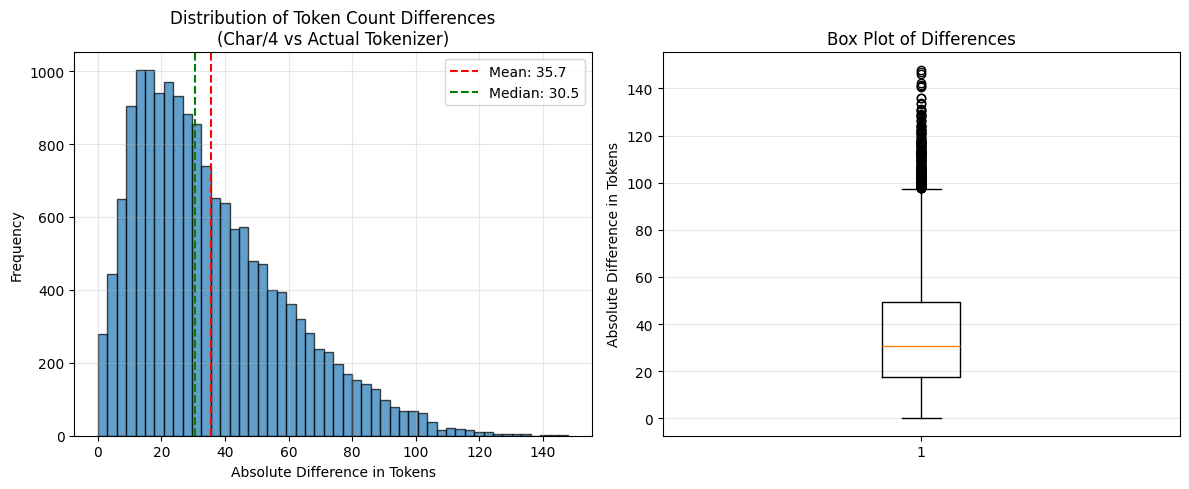


Plot saved to: token_difference_analysis.png


In [7]:
import numpy as np
import matplotlib.pyplot as plt

if differences:
    differences = np.array(differences)
    
    print("\n" + "=" * 70)
    print("DIFFERENCE STATISTICS (Old - New)")
    print("=" * 70)
    print(f"Mean difference:   {np.mean(differences):.2f} tokens")
    print(f"Median difference: {np.median(differences):.2f} tokens")
    print(f"Std difference:    {np.std(differences):.2f} tokens")
    print(f"Min difference:    {np.min(differences):.2f} tokens")
    print(f"Max difference:    {np.max(differences):.2f} tokens")
    
    # Plot histogram
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.hist(differences, bins=50, edgecolor='black', alpha=0.7)
    plt.xlabel('Absolute Difference in Tokens')
    plt.ylabel('Frequency')
    plt.title('Distribution of Token Count Differences\n(Char/4 vs Actual Tokenizer)')
    plt.axvline(np.mean(differences), color='red', linestyle='--', label=f'Mean: {np.mean(differences):.1f}')
    plt.axvline(np.median(differences), color='green', linestyle='--', label=f'Median: {np.median(differences):.1f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.boxplot(differences)
    plt.ylabel('Absolute Difference in Tokens')
    plt.title('Box Plot of Differences')
    plt.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('token_difference_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\nPlot saved to: token_difference_analysis.png")

## 6. Compare Examples

In [8]:
# Show some examples of differences
print("\n" + "=" * 70)
print("EXAMPLE COMPARISONS")
print("=" * 70)

with open(output_path, 'r', encoding='utf-8') as f:
    examples_shown = 0
    
    for line in f:
        if examples_shown >= 5:
            break
        
        line = line.strip()
        if not line:
            continue
        
        try:
            record = json.loads(line)
            
            if 'reasoning_tokens_old' in record:
                old_tokens = record['reasoning_tokens_old']
                new_tokens = record['reasoning_tokens']
                diff = abs(new_tokens - old_tokens)
                
                response = record.get('response', '')
                thinking = extract_thinking(response)
                
                print(f"\nExample {examples_shown + 1}:")
                print(f"  Thinking (first 100 chars): {thinking[:100]}...")
                print(f"  Old (char/4): {old_tokens:.1f} tokens")
                print(f"  New (actual): {new_tokens:.1f} tokens")
                print(f"  Difference: {diff:.1f} tokens ({(diff/old_tokens*100):.1f}%)")
                
                examples_shown += 1
        except:
            continue


EXAMPLE COMPARISONS


## 7. Batch Processing (Optional)

In [13]:
# Batch process multiple files
def batch_process_files(file_list, model_path, output_dir):
    """
    Process multiple JSONL files.
    
    Args:
        file_list: List of input file paths
        model_path: Path to model
        output_dir: Output directory
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Load tokenizer once
    print(f"Loading tokenizer from: {model_path}")
    tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
    print(f"Tokenizer loaded\n")
    
    for input_file in file_list:
        input_path = Path(input_file)
        if not input_path.exists():
            print(f"Skipping (not found): {input_file}")
            continue
        
        output_path = output_dir / input_path.name
        
        print(f"Processing: {input_file}")
        print(f"Output:     {output_path}")
        
        processed = 0
        with open(input_path, 'r', encoding='utf-8') as fin, \
             open(output_path, 'w', encoding='utf-8') as fout:
            
            for line in tqdm(fin, desc=f"  {input_path.name}"):
                line = line.strip()
                if not line:
                    continue
                
                try:
                    record = json.loads(line)
                    updated = recalculate_reasoning_tokens(record, tokenizer)
                    fout.write(json.dumps(updated, ensure_ascii=False) + '\n')
                    processed += 1
                except:
                    continue
        
        print(f"  Processed: {processed} records\n")



file_list = [
    "./0_raw/gsm8k/gsm8k_train_low.jsonl",
    "./0_raw/gsm8k/gsm8k_train_med.jsonl",
    "./0_raw/gsm8k/gsm8k_train_high.jsonl",
    "./0_raw/compmath/compmath_train_low.jsonl",
    "./0_raw/compmath/compmath_train_med.jsonl",
    "./0_raw/compmath/compmath_train_high.jsonl",
]
batch_process_files(file_list, MODEL_PATH, "./0_raw1")

Loading tokenizer from: /mnt/dataset1/pretrained_fm/gpt-oss-20b
Tokenizer loaded

Processing: ./0_raw/gsm8k/gsm8k_train_low.jsonl
Output:     0_raw1/gsm8k_train_low.jsonl


  gsm8k_train_low.jsonl: 32266it [00:06, 4964.71it/s]


  Processed: 32266 records

Processing: ./0_raw/gsm8k/gsm8k_train_med.jsonl
Output:     0_raw1/gsm8k_train_med.jsonl


  gsm8k_train_med.jsonl: 27661it [00:10, 2514.73it/s]


  Processed: 27661 records

Processing: ./0_raw/gsm8k/gsm8k_train_high.jsonl
Output:     0_raw1/gsm8k_train_high.jsonl


...

  Processed: 16524 records

Processing: ./0_raw/compmath/compmath_train_med.jsonl
Output:     0_raw1/compmath_train_med.jsonl


  compmath_train_med.jsonl: 16003it [00:08, 1874.16it/s]


  Processed: 16003 records

Processing: ./0_raw/compmath/compmath_train_high.jsonl
Output:     0_raw1/compmath_train_high.jsonl


  compmath_train_high.jsonl: 14945it [00:13, 1077.76it/s]


  Processed: 14945 records



In [14]:
file_list = [
    "/home/vlai-gpt-oss/LLaMA-OSS/LLaMA-Factory/data/final_data/final_sft/high_sft.jsonl",
    "/home/vlai-gpt-oss/LLaMA-OSS/LLaMA-Factory/data/final_data/final_sft/low_sft.jsonl",
    "/home/vlai-gpt-oss/LLaMA-OSS/LLaMA-Factory/data/final_data/final_sft/medium_sft.jsonl",
    "/home/vlai-gpt-oss/LLaMA-OSS/LLaMA-Factory/data/final_data/merged_grpo.jsonl", 
]
batch_process_files(file_list, MODEL_PATH, "./final_data1")

Loading tokenizer from: /mnt/dataset1/pretrained_fm/gpt-oss-20b
Tokenizer loaded

Processing: /home/vlai-gpt-oss/LLaMA-OSS/LLaMA-Factory/data/final_data/final_sft/high_sft.jsonl
Output:     final_data1/high_sft.jsonl


  high_sft.jsonl: 8602it [00:08, 1031.02it/s]


  Processed: 8602 records

Processing: /home/vlai-gpt-oss/LLaMA-OSS/LLaMA-Factory/data/final_data/final_sft/low_sft.jsonl
Output:     final_data1/low_sft.jsonl


  low_sft.jsonl: 6179it [00:02, 2628.32it/s]


  Processed: 6179 records

Processing: /home/vlai-gpt-oss/LLaMA-OSS/LLaMA-Factory/data/final_data/final_sft/medium_sft.jsonl
Output:     final_data1/medium_sft.jsonl


  medium_sft.jsonl: 7641it [00:04, 1748.83it/s]


  Processed: 7641 records

Processing: /home/vlai-gpt-oss/LLaMA-OSS/LLaMA-Factory/data/final_data/merged_grpo.jsonl
Output:     final_data1/merged_grpo.jsonl


  merged_grpo.jsonl: 874it [00:00, 54360.82it/s]


  Processed: 874 records



In [15]:
file_list = [
    "/home/vlai-gpt-oss/LLaMA-OSS/LLaMA-Factory/data/1_fbl/compmath/compmath_train_high_fbl.jsonl",
    "/home/vlai-gpt-oss/LLaMA-OSS/LLaMA-Factory/data/1_fbl/compmath/compmath_train_low_fbl.jsonl",
    "/home/vlai-gpt-oss/LLaMA-OSS/LLaMA-Factory/data/1_fbl/compmath/compmath_train_med_fbl.jsonl",
    "/home/vlai-gpt-oss/LLaMA-OSS/LLaMA-Factory/data/1_fbl/gsm8k/gsm8k_train_high_fbl.jsonl",
    "/home/vlai-gpt-oss/LLaMA-OSS/LLaMA-Factory/data/1_fbl/gsm8k/gsm8k_train_low_fbl.jsonl",
    "/home/vlai-gpt-oss/LLaMA-OSS/LLaMA-Factory/data/1_fbl/gsm8k/gsm8k_train_med_fbl.jsonl",
    "/home/vlai-gpt-oss/LLaMA-OSS/LLaMA-Factory/data/1_fbl/rejected/compmath/compmath_train_high_rejected.jsonl",
    "/home/vlai-gpt-oss/LLaMA-OSS/LLaMA-Factory/data/1_fbl/rejected/compmath/compmath_train_low_rejected.jsonl",
    "/home/vlai-gpt-oss/LLaMA-OSS/LLaMA-Factory/data/1_fbl/rejected/compmath/compmath_train_med_rejected.jsonl",
    "/home/vlai-gpt-oss/LLaMA-OSS/LLaMA-Factory/data/1_fbl/rejected/gsm8k/gsm8k_train_high_rejected.jsonl",
    "/home/vlai-gpt-oss/LLaMA-OSS/LLaMA-Factory/data/1_fbl/rejected/gsm8k/gsm8k_train_low_rejected.jsonl",
    "/home/vlai-gpt-oss/LLaMA-OSS/LLaMA-Factory/data/1_fbl/rejected/gsm8k/gsm8k_train_med_rejected.jsonl",
    
]
batch_process_files(file_list, MODEL_PATH, "./1_fbl1")

Loading tokenizer from: /mnt/dataset1/pretrained_fm/gpt-oss-20b
Tokenizer loaded

Processing: /home/vlai-gpt-oss/LLaMA-OSS/LLaMA-Factory/data/1_fbl/compmath/compmath_train_high_fbl.jsonl
Output:     1_fbl1/compmath_train_high_fbl.jsonl


  compmath_train_high_fbl.jsonl: 12551it [00:10, 1155.46it/s]


  Processed: 12551 records

Processing: /home/vlai-gpt-oss/LLaMA-OSS/LLaMA-Factory/data/1_fbl/compmath/compmath_train_low_fbl.jsonl
Output:     1_fbl1/compmath_train_low_fbl.jsonl


  compmath_train_low_fbl.jsonl: 13183it [00:03, 4280.71it/s]


  Processed: 13183 records

Processing: /home/vlai-gpt-oss/LLaMA-OSS/LLaMA-Factory/data/1_fbl/compmath/compmath_train_med_fbl.jsonl
Output:     1_fbl1/compmath_train_med_fbl.jsonl


...

  Processed: 653 records

Processing: /home/vlai-gpt-oss/LLaMA-OSS/LLaMA-Factory/data/1_fbl/rejected/gsm8k/gsm8k_train_low_rejected.jsonl
Output:     1_fbl1/gsm8k_train_low_rejected.jsonl


  gsm8k_train_low_rejected.jsonl: 1949it [00:00, 4328.62it/s]


  Processed: 1949 records

Processing: /home/vlai-gpt-oss/LLaMA-OSS/LLaMA-Factory/data/1_fbl/rejected/gsm8k/gsm8k_train_med_rejected.jsonl
Output:     1_fbl1/gsm8k_train_med_rejected.jsonl


  gsm8k_train_med_rejected.jsonl: 812it [00:00, 1967.40it/s]

  Processed: 812 records



## Summary

This notebook:
1. Loads the actual model tokenizer
2. Extracts thinking content from `<think>` tags
3. Counts tokens using the real tokenizer
4. Updates the `reasoning_tokens` field
5. Analyzes differences between char/4 approximation and actual token count

The recalculated values are more accurate and should be used for length-based filtering.